In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[0], 'GPU') ###

import hmc_1hl as hmc

In [3]:
L = 1
np.array([1+1/6, 1+2/6, 1+3/6, 1+4/6, 1+5/6, 2, 2+1/3, 2+2/3, 3, 3+1/3, 3+2/3, 4]) * L

array([1.16666667, 1.33333333, 1.5       , 1.66666667, 1.83333333,
       2.        , 2.33333333, 2.66666667, 3.        , 3.33333333,
       3.66666667, 4.        ])

In [ ]:
[4000, 6000]

In [13]:
d = 50
alpha = 1.5
gamma = 1
Delta = 0.1
vlaw = 'ones'
k = int(gamma * d)

sig = lambda x: (tf.nn.tanh(2*x) - 0.729477*x) / 0.321129

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 4000,
}

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)

In [14]:
W0, v, X, Y = hmc.data_generate(d, alpha, gamma, sig, Delta, vlaw)
Ws_info = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=True)
test_info = hmc.test_error(Ws_info, W0, v, sig, Xtest)

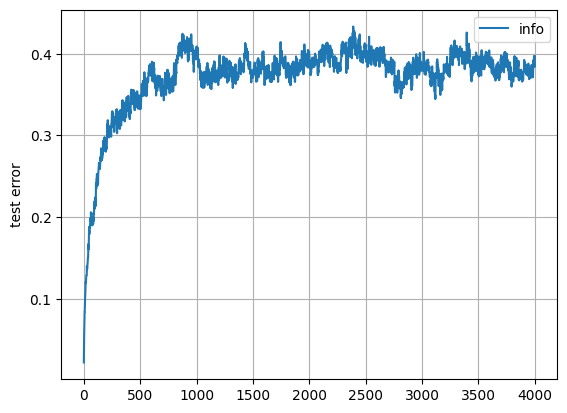

In [15]:
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
plt.show()